# Assignment 4
### BASIC STATISTICS
By **Mohan Sirumalla**
***


## Problem Statement : Hospital Patient Data Analysis
Context:
A hospital maintains patient records including admission details, department, diagnosis, doctor, and bill amount. You have two datasets: one with patient info and another with billing details. Some patients have blank bill amounts, and there are multiple rows for the same patient due to follow-ups.
Tasks:

1. Load the patient dataset and show summary with info().
2.	Select only the columns relevant for billing: ['PatientID', 'Department', 'Doctor', 'BillAmount'].
3.	Drop administrative columns like ['ReceptionistID', 'CheckInTime'].
4.	Use groupby to find total bill amount per department.
5.	Remove duplicate patient records based on PatientID.
6.	Fill missing BillAmount values with the mean bill amount.
7.	Merge the billing dataset with patient dataset on PatientID.
8.	Concatenate an additional DataFrame that contains new patients for the current week (row-wise).
9.	Concatenate new billing category columns like ['InsuranceCovered', 'FinalAmount'] (column-wise).

Expected Outcome:
•	Final cleaned dataset with accurate billing info.
•	All missing values handled, merged dataset across PatientID.
•	Ability to perform further analytics on department-wise revenue or doctor performance.


In [1]:
# Load the dataset
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Load the patient dataset and show summary with info().

#df_billing= pd.read_csv("Billing_Data.csv")
df_patient= pd.read_csv("Patient_Data.csv")
df_patient.info

<bound method DataFrame.info of    PatientID     Name   Department     Doctor  BillAmount  ReceptionistID  \
0        101    Alice   Cardiology  Dr. Smith      5000.0               1   
1        102      Bob    Neurology   Dr. John         NaN               2   
2        103  Charlie  Orthopedics    Dr. Lee      7500.0               1   
3        104    David   Cardiology  Dr. Smith      6200.0               3   
4        105      Eva  Dermatology   Dr. Rose         NaN               2   
5        101    Alice   Cardiology  Dr. Smith      5000.0               1   

        CheckInTime  
0  2023-01-10 09:00  
1  2023-01-11 10:30  
2  2023-01-12 11:00  
3  2023-01-13 12:00  
4  2023-01-14 08:45  
5  2023-01-10 09:00  >

In [3]:
#Select only the columns relevant for billing: ['PatientID', 'Department', 'Doctor', 'BillAmount'].
df_rel_bill=df_patient[['PatientID', 'Department', 'Doctor', 'BillAmount']]
df_rel_bill

,PatientID,Department,Doctor,BillAmount
0,101,Cardiology,Dr. Smith,5000.0
1,102,Neurology,Dr. John,NaN
2,103,Orthopedics,Dr. Lee,7500.0
3,104,Cardiology,Dr. Smith,6200.0
4,105,Dermatology,Dr. Rose,NaN
5,101,Cardiology,Dr. Smith,5000.0


In [4]:
#Drop administrative columns like ['ReceptionistID', 'CheckInTime'].
df_patient= df_patient.drop(['ReceptionistID', 'CheckInTime'],axis=1)
df_patient

,PatientID,Name,Department,Doctor,BillAmount
0,101,Alice,Cardiology,Dr. Smith,5000.0
1,102,Bob,Neurology,Dr. John,NaN
2,103,Charlie,Orthopedics,Dr. Lee,7500.0
3,104,David,Cardiology,Dr. Smith,6200.0
4,105,Eva,Dermatology,Dr. Rose,NaN
5,101,Alice,Cardiology,Dr. Smith,5000.0


In [5]:
#Use groupby to find total bill amount per department.
df_patient.groupby(['Department']).agg(Total_Amount=('BillAmount', 'sum'))

,Total_Amount
Department,
Cardiology,16200.0
Dermatology,0.0
Neurology,0.0
Orthopedics,7500.0


In [6]:
# Remove duplicate patient records based on PatientID.
df_unique = df_patient.drop_duplicates(subset=['PatientID'], keep='first')

In [7]:
# Fill missing BillAmount values with the mean bill amount.
mean_BillAmount = df_unique['BillAmount'].mean()
df_unique.loc[df_unique['BillAmount'].isna(), 'BillAmount'] = mean_BillAmount

In [8]:
df_unique

,PatientID,Name,Department,Doctor,BillAmount
0,101,Alice,Cardiology,Dr. Smith,5000.000000
1,102,Bob,Neurology,Dr. John,6233.333333
2,103,Charlie,Orthopedics,Dr. Lee,7500.000000
3,104,David,Cardiology,Dr. Smith,6200.000000
4,105,Eva,Dermatology,Dr. Rose,6233.333333


In [10]:
# Merge the billing dataset with patient dataset on PatientID.
df_billing= pd.read_csv("Billing_Data.csv")
df_billing


,PatientID,InsuranceCovered,FinalAmount
0,101,2000,3000
1,102,1500,3500
2,103,2500,5000
3,104,3000,3200
4,105,1000,4000


In [11]:
#merged_data
merged_data = pd.merge(df_billing, df_unique, on='PatientID', how='inner')

merged_data

,PatientID,InsuranceCovered,FinalAmount,Name,Department,Doctor,BillAmount
0,101,2000,3000,Alice,Cardiology,Dr. Smith,5000.000000
1,102,1500,3500,Bob,Neurology,Dr. John,6233.333333
2,103,2500,5000,Charlie,Orthopedics,Dr. Lee,7500.000000
3,104,3000,3200,David,Cardiology,Dr. Smith,6200.000000
4,105,1000,4000,Eva,Dermatology,Dr. Rose,6233.333333


In [13]:
merged_data['FinalAmount']=merged_data['BillAmount']-merged_data['InsuranceCovered']


In [14]:
merged_data

,PatientID,InsuranceCovered,FinalAmount,Name,Department,Doctor,BillAmount
0,101,2000,3000.000000,Alice,Cardiology,Dr. Smith,5000.000000
1,102,1500,4733.333333,Bob,Neurology,Dr. John,6233.333333
2,103,2500,5000.000000,Charlie,Orthopedics,Dr. Lee,7500.000000
3,104,3000,3200.000000,David,Cardiology,Dr. Smith,6200.000000
4,105,1000,5233.333333,Eva,Dermatology,Dr. Rose,6233.333333


In [27]:
# Create a New Sample Data Set
new_data_patient = {
    "PatientID":[106,107,108],
    "Name":['Mohan','Sohan','Rohan'],
    "Department":['Cardiology','Neurology','Cardiology'],
    "Doctor":['Dr. Smith','Dr. John','Dr. Smith'],
    "BillAmount":[6000,5000,7000]
}
new_data_bill = {
    "PatientID":[106,107,108],
    "InsuranceCovered":[3000,1000,2000],
    "FinalAmount":[3000,4000,5000],
    
}
# New patient and bill dadta
df_new_data_patient= pd.DataFrame(new_data_patient)
df_new_data_bill = pd.DataFrame(new_data_bill)
df_current_patient =df_unique
df_current_billing = df_billing
#print (df_current_patient)
#print (df_current_billing)
combined_patinet = pd.concat([df_current_patient,df_new_data_patient],ignore_index=True)
combined_billing = pd.concat([df_current_billing,df_new_data_bill],ignore_index=True)
print (combined_patinet)
print(combined_billing)


   PatientID     Name   Department     Doctor   BillAmount
0        101    Alice   Cardiology  Dr. Smith  5000.000000
1        102      Bob    Neurology   Dr. John  6233.333333
2        103  Charlie  Orthopedics    Dr. Lee  7500.000000
3        104    David   Cardiology  Dr. Smith  6200.000000
4        105      Eva  Dermatology   Dr. Rose  6233.333333
5        106    Mohan   Cardiology  Dr. Smith  6000.000000
6        107    Sohan    Neurology   Dr. John  5000.000000
7        108    Rohan   Cardiology  Dr. Smith  7000.000000
   PatientID  InsuranceCovered  FinalAmount
0        101              2000         3000
1        102              1500         3500
2        103              2500         5000
3        104              3000         3200
4        105              1000         4000
5        106              3000         3000
6        107              1000         4000
7        108              2000         5000


In [28]:
#Final with Current and New data
combined_data = pd.merge(combined_patinet, combined_billing, on='PatientID', how='inner')
combined_data

,PatientID,Name,Department,Doctor,BillAmount,InsuranceCovered,FinalAmount
0,101,Alice,Cardiology,Dr. Smith,5000.000000,2000,3000
1,102,Bob,Neurology,Dr. John,6233.333333,1500,3500
2,103,Charlie,Orthopedics,Dr. Lee,7500.000000,2500,5000
3,104,David,Cardiology,Dr. Smith,6200.000000,3000,3200
4,105,Eva,Dermatology,Dr. Rose,6233.333333,1000,4000
5,106,Mohan,Cardiology,Dr. Smith,6000.000000,3000,3000
6,107,Sohan,Neurology,Dr. John,5000.000000,1000,4000
7,108,Rohan,Cardiology,Dr. Smith,7000.000000,2000,5000


In [30]:
#Ability to perform further analytics on department-wise revenue or doctor performance.
#Department wise revewne
dept_wise=combined_data.groupby('Department')['BillAmount'].sum()
dept_wise

Department
Cardiology     24200.000000
Dermatology     6233.333333
Neurology      11233.333333
Orthopedics     7500.000000
Name: BillAmount, dtype: float64

<Axes: xlabel='Department', ylabel='BillAmount'>

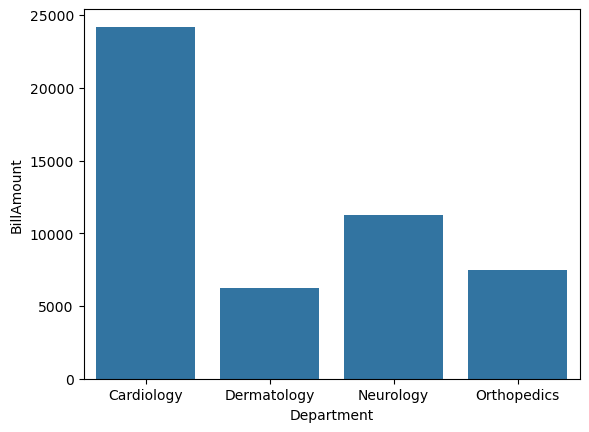

In [37]:
sns.barplot(dept_wise)


In [38]:
doctor_wise=combined_data.groupby('Doctor')['BillAmount'].sum()
doctor_wise

Doctor
Dr. John     11233.333333
Dr. Lee       7500.000000
Dr. Rose      6233.333333
Dr. Smith    24200.000000
Name: BillAmount, dtype: float64

([0, 1, 2, 3],
 [Text(0, 0, 'Dr. Smith'),
  Text(1, 0, 'Dr. John'),
  Text(2, 0, 'Dr. Lee'),
  Text(3, 0, 'Dr. Rose')])

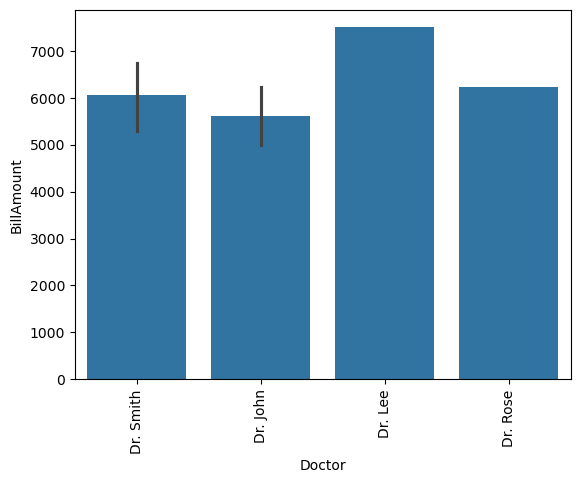

In [59]:
sns.barplot(x='Doctor',y='BillAmount',data=combined_data)
#sns.boxplot(x='Doctor',y='BillAmount',data=combined_data)
plt.xticks(rotation=90, ha='center')

([0, 1, 2, 3],
 [Text(0, 0, 'Cardiology'),
  Text(1, 0, 'Neurology'),
  Text(2, 0, 'Orthopedics'),
  Text(3, 0, 'Dermatology')])

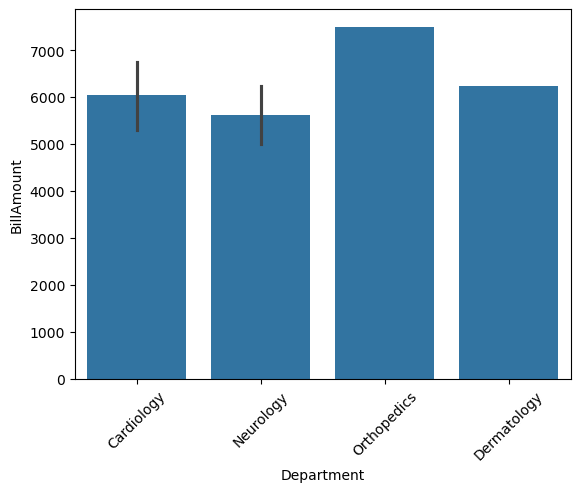

In [60]:
sns.barplot(x='Department',y='BillAmount',data=combined_data)
plt.xticks(rotation=45, ha='center')